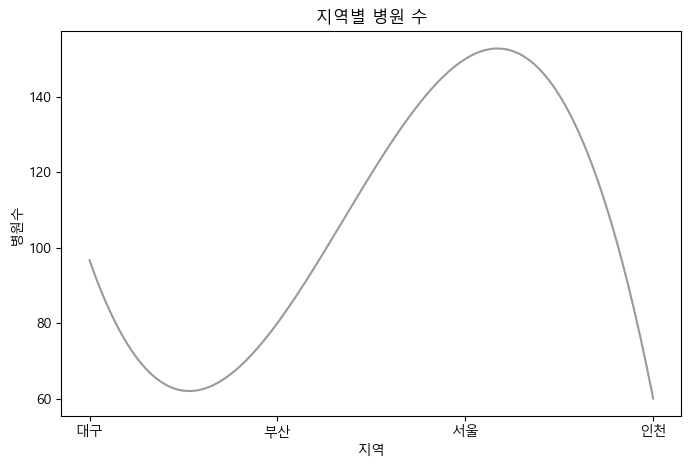

In [9]:

# 반드시 pandas는 import하여 사용
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# 데이터 생성하기
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [100000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# 데이터 병합 (지역 기준)
merged = pd.merge(df1, df2, on="지역", how="outer")

# 결측치 처리
# 총인구 없는 값 -> 평균으로 채우기
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())

# 결과 확인
merged

# 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 설정
plt.figure(figsize=(8, 5))

# x를 숫자로 변환
x = np.arange(len(merged['지역']))
y = merged['병원수']

# 부드러운 곡선용 데이터 생성
x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = make_interp_spline(x, y)(x_smooth)

# 곡선 그래프
plt.plot(x_smooth, y_smooth, color='black', alpha=0.4)
# x축을 다시 지역 이름으로 표시
plt.xticks(x, merged["지역"])

plt.title("지역별 병원 수")
plt.xlabel("지역")
plt.ylabel("병원수")

# 그래프 출력
plt.show()